In [131]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestRegressor
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras

In [132]:
df=pd.read_csv('/content/ESG_Data_Emerging new.csv')

In [133]:
df.head() # check the first rows of the dataset

,No,Year,Country_ID,Bank_ID,IB,DTD_PB,DTC_PB,ESGS,ESGcom,ESGC,...,TA,IB.1,EG,INF,HHII,COVID,GOV,MIP,REG,LNTA
0,1,2016,1,1,1,"10,420881","13,343928","10,42","10,42",100,...,"4764000000000,00%",1,"5,5614908","1,6174881","7,683712",0,"0,97407607","3,534691","0,95991838","24,58701"
1,8,2016,1,2,0,"12,057114","14,390203","61,72","61,72",100,...,"7033000000000,00%",0,"5,5614908","1,6174881","7,683712",0,"0,97407607","3,534691","0,95991838","24,97647"
2,15,2016,1,3,0,"35,223664","43,347386","56,67","56,67",100,...,"6099000000000,00%",0,"5,5614908","1,6174881","7,683712",0,"0,97407607","3,534691","0,95991838","24,83395"
3,22,2016,1,4,0,"27,396457","32,671026","34,82","34,82",100,...,"12200000000000,00%",0,"5,5614908","1,6174881","7,683712",0,"0,97407607","3,534691","0,95991838","25,52719"
4,29,2016,1,5,1,"18,592285","22,642981",NaN,NaN,NaN,...,"3330000000000,00%",1,"5,5614908","1,6174881","7,683712",0,"0,97407607","3,534691","0,95991838","24,22879"


In [134]:
df.info() # Check the data type of thr dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1092 entries, 0 to 1091
Data columns (total 29 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   No          1092 non-null   int64 
 1   Year        1092 non-null   int64 
 2   Country_ID  1092 non-null   int64 
 3   Bank_ID     1092 non-null   int64 
 4   IB          1092 non-null   int64 
 5   DTD_PB      1014 non-null   object
 6   DTC_PB      1014 non-null   object
 7   ESGS        949 non-null    object
 8   ESGcom      949 non-null    object
 9   ESGC        949 non-null    object
 10  E           949 non-null    object
 11  S           949 non-null    object
 12  G           949 non-null    object
 13  ETA         1087 non-null   object
 14  NPL         1073 non-null   object
 15  CTI         1087 non-null   object
 16  TDTA        1087 non-null   object
 17  REVDIV      1087 non-null   object
 18  LOANGR      1071 non-null   object
 19  TA          1087 non-null   object
 20  IB.1    

In [135]:
df.shape #check the shape of the dataset

(1092, 29)

In [136]:
df.drop(['No','Year','Country_ID','Bank_ID'],axis=1,inplace=True) #drop less important features

In [137]:
df['COVID'].unique() # check the unique value of target variable

array([0, 1])

In [138]:
df.isnull().sum() # Check the null values

,0
IB,0
DTD_PB,78
DTC_PB,78
ESGS,143
ESGcom,143
ESGC,143
E,143
S,143
G,143
ETA,5


In [139]:
df['DTD_PB']=df['DTD_PB'].fillna(df['DTD_PB'].mode()[0]) # missing value imputation by mode
df['DTD_PB']=df['DTD_PB'].str.replace(',','') # replace coma to covert the data numerical from categorica
df['DTD_PB'] = df['DTD_PB'].astype(int) # convert the data into int


In [140]:
df['DTC_PB']=df['DTC_PB'].fillna(df['DTC_PB'].mode()[0]) # missing value imputation by mode
df['DTC_PB']=df['DTC_PB'].str.replace(',','') # replace coma to covert the data numerical from categorical
df['DTC_PB']=df['DTC_PB'].astype(int) # convert the data into int

In [141]:
df['ESGS']=df['ESGS'].fillna(df['ESGC'].mode()[0]) # missing value imputation by mode
df['ESGS']=df['ESGS'].str.replace(',','') # replace coma to covert the data numerical from categorical
df['ESGS']=df['ESGS'].astype(int) # convert the data into int

In [142]:
df['ESGcom']=df['ESGcom'].fillna(df['ESGcom'].mode()[0]) #missing value imputation by mode, explicitly using the first mode value
df['ESGcom']=df['ESGcom'].str.replace(',','') # replace coma to convert the data numerical from categorical
df['ESGcom']=df['ESGcom'].astype(int) #convert data into integer

In [143]:
df['ESGC']=df['ESGC'].fillna(df['ESGC'].mode()[0]) #missing value interputation by mode, explitically using the first mode value
df['ESGC']=df['ESGC'].str.replace(',','') #replace coma to convert the data numerical from categorical
df['ESGC']=df['ESGC'].astype(int) # convert data into integer

In [144]:
df['E']=df['E'].fillna(df['E'].mode()[0]) # missing value imputation by mode, explitically using the first value
df['E']=df['E'].str.replace(',','') # replace coma to conver the data numerical from categorical
df['E']=df['E'].astype(int) # convert data into integer

In [145]:
df['S']=df['S'].fillna(df['S'].mode()[0]) #missing value imputation by mode, explitically using the first value
df['S']=df['S'].str.replace(',','') #replace coma to convert the data numirical from categorical
df['S']=df['S'].astype(int) # convert data into integer

In [146]:
df['G']=df['G'].fillna(df['G'].mode()[0]) #missing value imputation by mode, explitically using the firat value
df['G']=df['G'].str.replace(',','') #replace coma to convert the data numirical from categorical
df['G']=df['G'].astype(int) #  convert data into integer

In [147]:
df['ETA']=df['ETA'].fillna(df['ETA'].mode()[0]) # missing value imputation by mode, expliticall using the first value
df['ETA']=df['ETA'].str.replace(',','') # replace coma to convert the data numerical from categorical
df['ETA']=df['ETA'].astype(int) #convert data into integer

In [148]:
df['NPL']=df['NPL'].fillna(df['NPL'].mode()[0]) # missing value imputation by mode, expliticall using the first value
df['NPL']=df['NPL'].str.replace(',','') # replace coma to convert the data numerical from categorical
df['NPL']=df['NPL'].astype(int) #convert data into integer

In [149]:
df['CTI']=df['CTI'].fillna(df['CTI'].mode()[0]) # missing value imputation by mode, expliticall using the first value
df['CTI']=df['CTI'].str.replace(',','') # replace coma to convert the data numerical from categorical
df['CTI']=df['CTI'].astype(int) #convert data into integer

In [150]:
df['TDTA']=df['TDTA'].fillna(df['TDTA'].mode()[0]) # missing value imputation by mode, expliticall using the first value
df['TDTA']=df['TDTA'].str.replace(',','') # replace coma to convert the data numerical from categorical
df['TDTA']=df['TDTA'].astype(int) #convert data into integer

In [151]:
df['REVDIV']=df['REVDIV'].fillna(df['REVDIV'].mode()[0]) # missing value imputation by mode, expliticall using the first value
df['REVDIV']=df['REVDIV'].str.replace(',','') # replace coma to convert the data numerical from categorical
df['REVDIV']=df['REVDIV'].astype(int) #convert data into integer

In [152]:
df['LOANGR']=df['LOANGR'].fillna(df['LOANGR'].mode()[0]) # missing value imputation by mode, expliticall using the first value
df['LOANGR']=df['LOANGR'].str.replace(',','') # replace coma to convert the data numerical from categorical
df['LOANGR']=df['LOANGR'].astype(int) #convert data into integer

In [153]:
df['TA']=df['TA'].fillna(df['TA'].mode()[0]) # missing value imputation by mode, expliticall using the first value
df['TA']=df['TA'].str.replace(',','').str.replace('%','') # replace coma and percentage to convert the data numerical from categorical
df['TA']=df['TA'].astype(int) #convert data into integer

In [154]:
df['EG']=df['EG'].str.replace(',','') # replace coma to convert the data numerical from categorical
df['EG']=df['EG'].astype(int) #convert data into integer

In [155]:
df['INF']=df['INF'].fillna(df['INF'].mode()[0]) # missing value imputation by mode, expliticall using the first value
df['INF']=df['INF'].str.replace(',','') # replace coma to convert the data numerical from categorical
df['INF']=df['INF'].astype(int) #convert data into integer

In [156]:
df['HHII']=df['HHII'].str.replace(',','') # replace coma to convert the data numerical from categorical
df['HHII']=df['HHII'].astype(int) #convert data into integer

In [157]:
df['GOV']=df['GOV'].str.replace(',','') # replace coma to convert the data numerical from categorical
df['GOV']=df['GOV'].astype(int) #convert data into integer

In [158]:
df['MIP']=df['MIP'].str.replace(',','') # replace coma to convert the data numerical from categorical
df['MIP']=df['MIP'].astype(int) #convert data into integer

In [159]:
df['REG']=df['REG'].str.replace(',','') # replace coma to convert the data numerical from categorical
df['REG']=df['REG'].astype(int) #convert data into integer

In [160]:
df['LNTA']=df['LNTA'].fillna(df['LNTA'].mode()[0]) #missing value imputation by mode, explicitly using the first mode value
df['LNTA']=df['LNTA'].str.replace(',','') # replace coma to convert the data numerical from categorical
df['LNTA']=df['LNTA'].astype(int) #convert data into integer

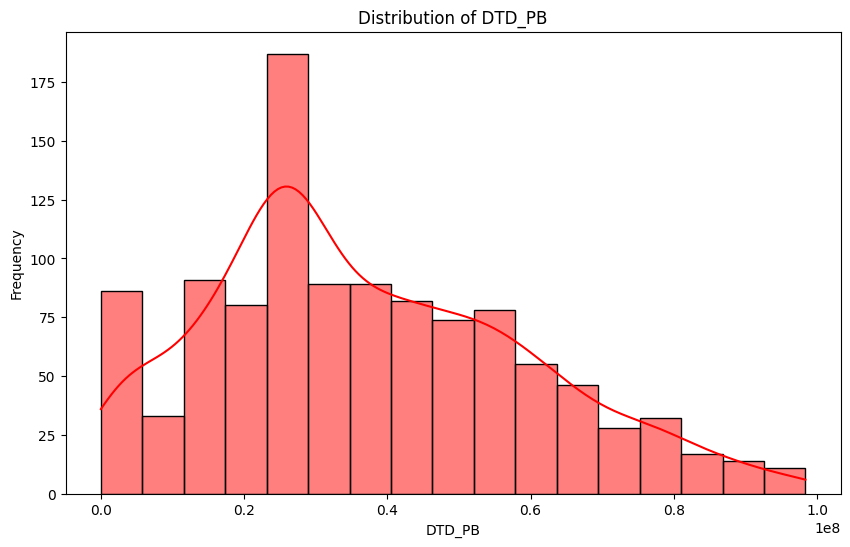

In [161]:
plt.figure(figsize=(10,6)) # set the figure size
sns.histplot(df['DTD_PB'],kde=True,color='red') # histogram plot
plt.title('Distribution of DTD_PB') # title name of the plot
plt.xlabel('DTD_PB') # x-label of the plot
plt.ylabel('Frequency') # y-label of the plot
plt.show() # display the plot

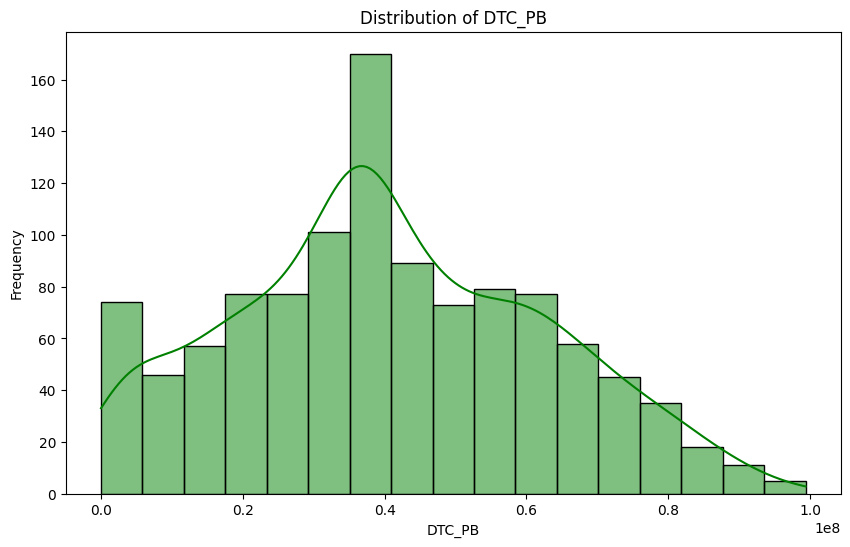

In [162]:
plt.figure(figsize=(10,6)) # set the figure size
sns.histplot(df['DTC_PB'],kde=True,color='green') # histogram plot
plt.title('Distribution of DTC_PB') # title name of the plot
plt.xlabel('DTC_PB') # x-label of the plot
plt.ylabel('Frequency') # y-label of the plot
plt.show() # display the plot

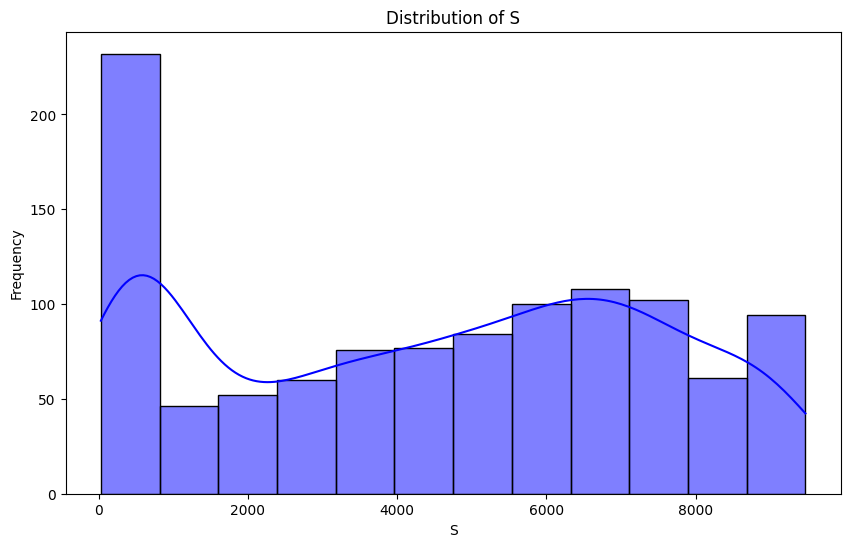

In [163]:
plt.figure(figsize=(10,6)) # set the figure size
sns.histplot(df['S'],kde=True,color='blue') # histogram plot
plt.title('Distribution of S')#title name of the plot
plt.xlabel('S') # x-label of the plot
plt.ylabel('Frequency') # y-label of the plot
plt.show() # display the plot

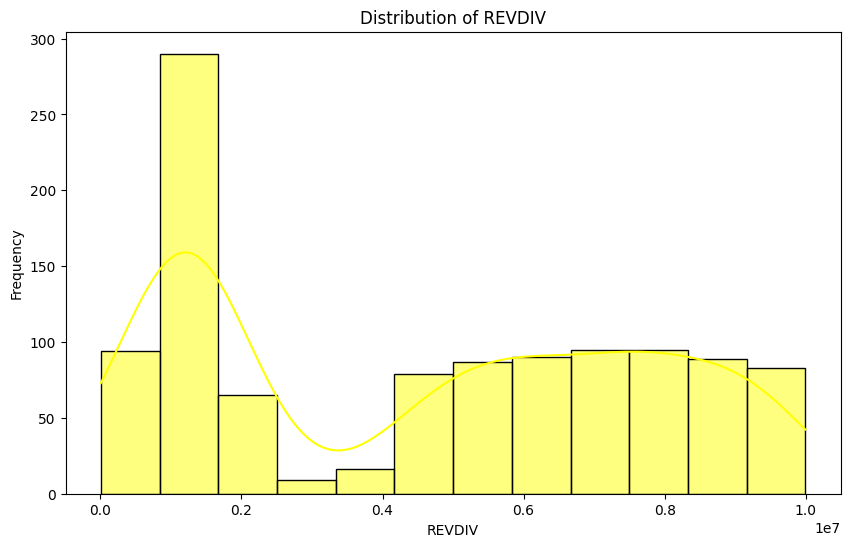

In [164]:
plt.figure(figsize=(10,6)) # set the figure size
sns.histplot(df['REVDIV'],kde=True,color='Yellow') # histogram plot
plt.title('Distribution of REVDIV') # title name of the plot
plt.xlabel('REVDIV') # x-label of the plot
plt.ylabel('Frequency') # y-label of the plot
plt.show() # display the plot

In [166]:
df['COVID'].value_counts()

,count
COVID,
0,780
1,312


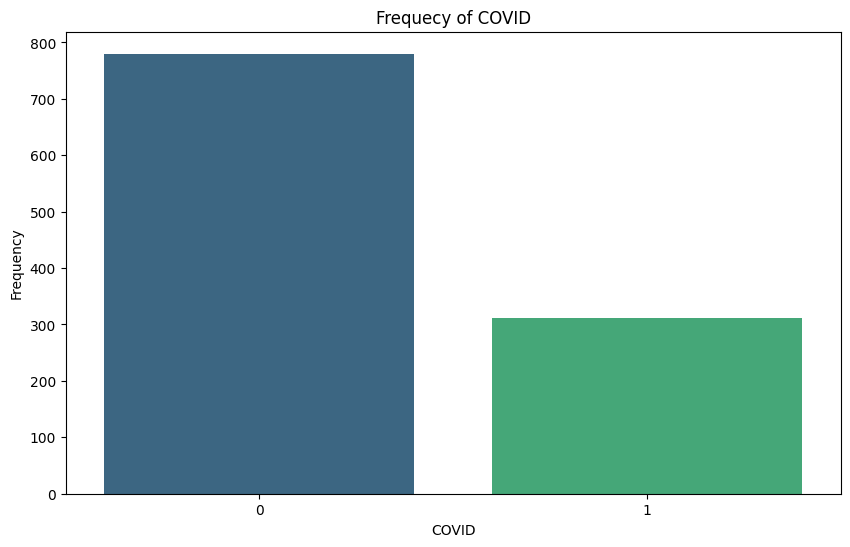

In [167]:
plt.figure(figsize=(10,6)) #set the figure
sns.countplot(x='COVID',data=df,palette='viridis')
plt.title('Frequecy of COVID') #Title of the plot
plt.xlabel('COVID') # label of x-axis
plt.ylabel('Frequency') #label of y-axis
plt.show() #Display the plot

In [169]:
x=df.drop(['COVID'],axis=1) # dependent variable
y=df['COVID'] # target variable

In [170]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=40) # Split the data into training and testing sets for machine learning

In [171]:
scaler=StandardScaler() ## Create an instance of StandardScaler
x_train_scaled=scaler.fit_transform(x_train) # Fit the scaler on the training data and transform it
x_test_scaled=scaler.transform(x_test)  ## Transform the test data using the same scaler

In [172]:
tf.random.set_seed(42) #set the seed of tansorflow

In [173]:
model=keras.Sequential([keras.layers.Flatten(input_shape=(24,)),
                        keras.layers.Dense(20,activation='relu'),
                        keras.layers.Dense(2,activation='sigmoid')]) # Define a Sequential neural network with input flattening, one hidden ReLU layer, and a sigmoid-activated output layer for binary/multiclass classification

In [174]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [175]:
history=model.fit(x_train_scaled,y_train,validation_split=0.1,epochs=100)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7198 - loss: 0.6233 - val_accuracy: 0.6932 - val_loss: 0.6130
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7259 - loss: 0.5691 - val_accuracy: 0.7045 - val_loss: 0.5709
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7394 - loss: 0.5380 - val_accuracy: 0.7159 - val_loss: 0.5410
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7532 - loss: 0.5169 - val_accuracy: 0.7273 - val_loss: 0.5187
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7630 - loss: 0.5005 - val_accuracy: 0.7500 - val_loss: 0.5012
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7765 - loss: 0.4866 - val_accuracy: 0.7614 - val_loss: 0.4874
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7799 - loss: 0.4744 - val_accuracy: 0.7614 - val_loss: 0.4759
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7857 - loss: 0.4635 - val_accuracy: 0.7727 - 

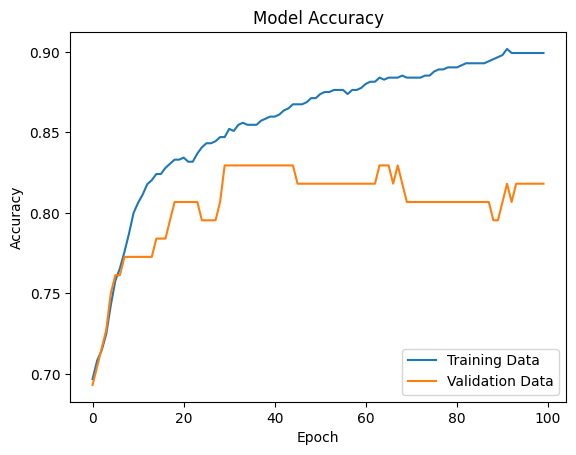

In [181]:
plt.plot(history.history['accuracy'])          # Plot training accuracy across epochs
plt.plot(history.history['val_accuracy'])      # Plot validation accuracy across epochs
plt.title('Model Accuracy')                    # Set plot title
plt.ylabel('Accuracy')                         # Label y-axis
plt.xlabel('Epoch')                            # Label x-axis
plt.legend(['Training Data', 'Validation Data'], loc='lower right')  # Add legend
plt.show()                                     # Display the accuracy curve


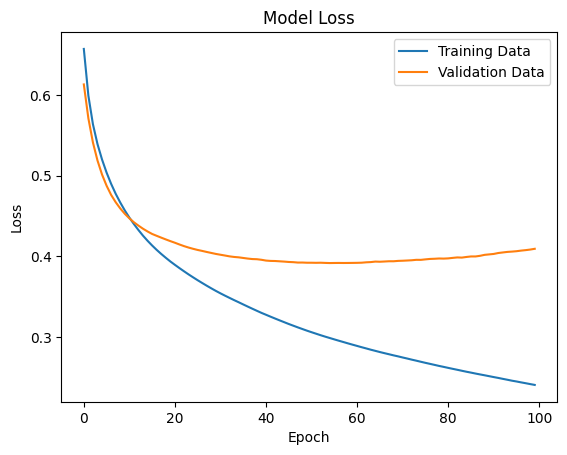

In [180]:
plt.plot(history.history['loss'])               # Plot training loss across epochs
plt.plot(history.history['val_loss'])           # Plot validation loss across epochs
plt.title('Model Loss')                         # Set plot title
plt.xlabel('Epoch')                             # Label x-axis
plt.ylabel('Loss')                              # Label y-axis
plt.legend(['Training Data', 'Validation Data'], loc='upper right')  # Add legend
plt.show()                                      # Display the loss curve
